In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.models import (resnet50, ResNet50_Weights)
from torchvision.models import (resnet18, ResNet18_Weights)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

from tqdm import tqdm
import math
from PIL import Image
import json
import time
import os

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [2]:
df = pd.read_parquet("Data/dipser_dataset.parquet", engine="pyarrow")

In [3]:
df["time_sec"] = (pd.to_datetime(df["time"]))

# convert it to 0-300
df["time_sec"] = (
    df.groupby("subject_experiment_id")["time_sec"]
    .transform(lambda x:
        (x - x.min())
        .dt.total_seconds()
        .astype(int)
    )
)
df.head()

,group,time,image_path,metadata,subject,experiment,self_labeling emotion,self_labeling attention,labeler_02 attention,labeler_04 attention,labeler_02 emotion,labeler_01 attention,labeler_03 emotion,labeler_03 attention,labeler_01 emotion,labeler_04 emotion,self_labeling emotionfilled,self_labeling attentionfilled,labeler_02 attentionfilled,labeler_04 attentionfilled,labeler_02 emotionfilled,labeler_01 attentionfilled,labeler_03 emotionfilled,labeler_03 attentionfilled,labeler_01 emotionfilled,labeler_04 emotionfilled,samsung_rotation_vector value0_mean,samsung_rotation_vector value0_std,samsung_rotation_vector value1_mean,samsung_rotation_vector value1_std,samsung_rotation_vector value2_mean,samsung_rotation_vector value2_std,samsung_rotation_vector value3_mean,samsung_rotation_vector value3_std,samsung_rotation_vector value4_mean,samsung_rotation_vector value4_std,lsm6dso_gyroscope value0_mean,lsm6dso_gyroscope value0_std,lsm6dso_gyroscope value1_mean,lsm6dso_gyroscope value1_std,lsm6dso_gyroscope value2_mean,lsm6dso_gyroscope value2_std,samsung_linear_acceleration_sensor value0_mean,samsung_linear_acceleration_sensor value0_std,samsung_linear_acceleration_sensor value1_mean,samsung_linear_acceleration_sensor value1_std,samsung_linear_acceleration_sensor value2_mean,samsung_linear_acceleration_sensor value2_std,opt3007_light value0_mean,opt3007_light value0_std,heart_rate,heart_rate_std,accel_magnitude_mean,accel_magnitude_std,gyro_magnitude_mean,gyro_magnitude_std,labeler_05 emotion,labeler_05 attention,labeler_05 emotionfilled,labeler_05 attentionfilled,invalid_reason,gender,age,race,subject_experiment_id,attention,subject_id,time_sec
0,group01,2026-05-08 10:40:43.047895,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_047895.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_047895.json,subject_01,experiment01,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109524,0.000163,-0.659717,0.000588,0.632875,0.000495,0.390186,0.000218,246.0,0.0,-0.006022,0.006482,-0.003838,0.003665,-0.000864,0.006845,0.052984,0.034713,-0.132399,0.047077,0.017549,0.043508,63.0,0.0,78.0,NaN,0.155556,0.041540,0.011095,0.005498,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,0
1,group01,2026-05-08 10:40:43.195317,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_195317.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_195317.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109485,0.000109,-0.660015,0.000520,0.632620,0.000426,0.390106,0.000225,246.0,0.0,-0.004508,0.005235,-0.004068,0.003267,-0.001026,0.005944,0.053056,0.036979,-0.124020,0.045047,0.012282,0.043478,63.0,0.0,78.0,NaN,0.148634,0.038779,0.009572,0.004378,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,0
2,group01,2026-05-08 10:40:43.295405,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_295405.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_295405.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109478,0.000101,-0.660194,0.000514,0.632473,0.000406,0.390043,0.000252,246.0,0.0,-0.004581,0.005193,-0.003897,0.003153,-0.000525,0.005644,0.054420,0.036670,-0.129478,0.044805,0.015730,0.040968,63.0,0.0,78.0,NaN,0.153129,0.038995,0.009384,0.004079,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,0
3,group01,2026-05-08 10:40:43.395835,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_395835.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_395835.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [4]:
# df.isna().sum().head(60)

In [5]:
df[['attention', 'image_path', 'age', 'gender']].isna().sum()

attention     0
image_path    0
age           0
gender        0
dtype: int64

In [6]:
sensor_cols = [
    col for col in df.columns
    if (
        (
            "sensor" in col.lower()
            or "acceleration" in col.lower()
            or "gyro" in col.lower()
            or "rotation" in col.lower()
            or "heart" in col.lower()
            or "light" in col.lower()
            or "accel" in col.lower()
        )
    )
]

df = df.drop(columns=sensor_cols)

In [30]:
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )])

transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=3, translate=(0.02, 0.02)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),

    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [31]:
# # keep middle frame
# df_sec = (
#     df.sort_values(["subject_experiment_id", "time_sec"])
#     .groupby(["subject_experiment_id", "time_sec"])
#     .apply(
#         lambda x:
#         x.iloc[len(x)//2])
#     .reset_index(drop=True))

# keep only 1 frame per second (the first)
df_sec = (df.sort_values(["subject_experiment_id", "time_sec"])
      .groupby(["subject_experiment_id", "time_sec"])
      .first()
      .reset_index())
df_sec.shape

(111754, 38)

In [32]:
reconstructed_sequences = []

for sequence_id, sequence_df in (df_sec.groupby("subject_experiment_id")):

    sequence_df = sequence_df.sort_values("time_sec")

    first_second = (sequence_df["time_sec"].min())
    last_second = (sequence_df["time_sec"].max())

    complete_seconds = pd.DataFrame({
        "time_sec": np.arange(
            first_second,
            last_second + 1)})

    reconstructed = (
        complete_seconds.merge(
            sequence_df,
            on="time_sec",
            how="left"))

    reconstructed["subject_experiment_id"] = sequence_id
    reconstructed["missing_visual_input"] = reconstructed["image_path"].isna().astype(int)
    
    reconstructed_sequences.append(reconstructed)

temporal_frame_dataset = pd.concat(reconstructed_sequences, ignore_index=True)

In [33]:
class TemporalFrameDataset(Dataset):

    def __init__(self, sequence_df, transform=None):

        self.df = sequence_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def load_image(self, image_path):

        # missing second
        if pd.isna(image_path):
            return Image.new("RGB",(224, 224))

        try:
            
            img = Image.open(image_path).convert("RGB")

        except Exception as e:
            
            print("Image loading error:", e)
            img = Image.new("RGB", (224, 224))

        return img

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        images = []

        for image_path in row["frames"]:

            img = self.load_image(image_path)

            if self.transform:
                img = self.transform(img)

            images.append(img)

        # shape:
        # (T, C, H, W)
        images = torch.stack(images)
        target = torch.tensor(row["target"], dtype=torch.float32)
        missing_flags = torch.tensor(row["missing_flags"], dtype=torch.float32)

        return images, missing_flags, target

In [34]:
SEQUENCE_LENGTH = 5

temporal_sequences = []

for sequence_id, sequence_df in temporal_frame_dataset.groupby("subject_experiment_id"):

    sequence_df = sequence_df.sort_values("time_sec").reset_index(drop=True)

    for i in range(SEQUENCE_LENGTH - 1, len(sequence_df)):

        target = sequence_df.iloc[i]["attention"]

        if pd.isna(target):
            continue

        history = sequence_df.iloc[i-SEQUENCE_LENGTH+1:i+1]

        temporal_sequences.append({
            "subject_experiment_id": sequence_id,
            "frames": history["image_path"].tolist(),
            "missing_flags": history["missing_visual_input"].tolist(),
            "target": target
        })

In [35]:
temporal_sequence_df = pd.DataFrame(temporal_sequences)

In [36]:
temporal_sequence_df.shape

(109817, 4)

### Train Test Split

In [37]:
subject_info = df[["subject_experiment_id", "subject_id", "gender", "age"]].drop_duplicates()

In [38]:
temporal_sequence_df = temporal_sequence_df.merge(
    subject_info,
    on="subject_experiment_id",
    how="left")

In [39]:
def count_ones(lst):
    if not isinstance(lst, (list, tuple)):
        return 0
    return sum(1 for x in lst if x == 1)

temporal_sequence_df['sum_missing'] = temporal_sequence_df['missing_flags'].apply(count_ones)

In [40]:
# remove cases where we have 3 out of 5 missing images in the sequence
temporal_sequence_df = temporal_sequence_df[temporal_sequence_df['sum_missing'] <=3]

In [41]:
subject_df = temporal_sequence_df[['subject_id', 'gender']].drop_duplicates()

train_sub, temp_sub = train_test_split(
    subject_df,
    test_size=0.3,
    stratify=subject_df['gender'],
    random_state=42)

# further break temp for balanced val and test
val_sub, test_sub = train_test_split(
    temp_sub,
    test_size=0.5,
    stratify=temp_sub['gender'],
    random_state=42)

train_subjects = train_sub['subject_id']
val_subjects = val_sub['subject_id']
test_subjects = test_sub['subject_id']

train_df = temporal_sequence_df[temporal_sequence_df["subject_id"].isin(train_subjects)]
val_df  = temporal_sequence_df[temporal_sequence_df["subject_id"].isin(val_subjects)]
test_df  = temporal_sequence_df[temporal_sequence_df["subject_id"].isin(test_subjects)]

In [42]:
train_dataset = TemporalFrameDataset(train_df, transform)
val_dataset = TemporalFrameDataset(val_df, transform)
test_dataset  = TemporalFrameDataset(test_df, transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

### Training

### 1st approach: ResNet50

In [43]:
class CNN_GRU(nn.Module):

    def __init__(self):

        super().__init__()

        backbone = models.resnet50(pretrained=True)

        # FREEZE BACKBONE

        for param in backbone.parameters():
            param.requires_grad = False
            
        # fine-tune only layers 3 and 4

        for param in backbone.layer3.parameters():
            param.requires_grad = True

        for param in backbone.layer4.parameters():
            param.requires_grad = True

        self.cnn = nn.Sequential(
            *list(backbone.children())[:-1])

        # TEMPORAL MODEL

        self.gru = nn.GRU(
            input_size=2049,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            dropout=0.3)

        # REGRESSION HEAD

        self.regressor = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1))

    def forward(self, images, missing_flags):

        # images:
        # (B, T, C, H, W)
        B, T, C, H, W = images.shape

        # CNN FEATURE EXTRACTION
        images = images.view(B * T, C, H, W)
        features = self.cnn(images)
        features = features.squeeze(-1).squeeze(-1)

        # back to temporal structure
        features = features.view(B, T, 2048)

        # APPEND MISSING FLAGS
        missing_flags = missing_flags.unsqueeze(-1)

        features = torch.cat([features, missing_flags], dim=-1)

        # TEMPORAL MODELING
        output, hidden = self.gru(features)
        final_hidden = hidden[-1]

        # REGRESSION
        prediction = self.regressor(final_hidden)

        return prediction.squeeze(1)

### 2nd approach: ResNet18

In [44]:
# class CNN_GRU(nn.Module):

#     def __init__(self):

#         super().__init__()

#         backbone = models.resnet18(pretrained=True)

#         # freeze backbone
#         for param in backbone.parameters():
#             param.requires_grad = False

#         # unfreeze layers 3 and 4
#         for param in backbone.layer3.parameters():
#             param.requires_grad = True

#         for param in backbone.layer4.parameters():
#             param.requires_grad = True

#         self.cnn = nn.Sequential(
#             *list(backbone.children())[:-1])

#         self.gru = nn.GRU(
#             input_size=513,
#             hidden_size=128,
#             num_layers=2,
#             batch_first=True,
#             dropout=0.3)

#         self.regressor = nn.Sequential(
#             nn.Linear(256, 128),
#             nn.ReLU(),
#             nn.Dropout(0.4),

#             nn.Linear(128, 64),
#             nn.ReLU(),
#             nn.Dropout(0.3),

#             nn.Linear(64, 1)
#         )

#     def forward(self, images, missing_flags):

#         B, T, C, H, W = images.shape

#         images = images.view(B * T, C, H, W)

#         features = self.cnn(images)

#         features = features.squeeze(-1).squeeze(-1)

#         features = features.view(B, T, 512)

#         missing_flags = missing_flags.unsqueeze(-1)

#         features = torch.cat(
#             [features, missing_flags],
#             dim=-1
#         )

#         output, _ = self.gru(features)

#         # temporal average pooling
#         temporal_features = output.mean(dim=1)

#         prediction = self.regressor(temporal_features)

#         return prediction.squeeze(1)

In [50]:
class CNN_GRU(nn.Module):

    def __init__(self):

        super().__init__()

        backbone = models.resnet18(pretrained=True)

        for param in backbone.parameters():
            param.requires_grad = False

        for param in backbone.layer3.parameters():
            param.requires_grad = True

        for param in backbone.layer4.parameters():
            param.requires_grad = True

        self.cnn = nn.Sequential(
            *list(backbone.children())[:-1]
        )

        self.feature_dropout = nn.Dropout(0.2)

        self.gru = nn.GRU(
            input_size=513,
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )

        self.temporal_norm = nn.LayerNorm(128)

        self.regressor = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1)
        )

    def forward(self, images, missing_flags):

        B, T, C, H, W = images.shape

        images = images.view(B * T, C, H, W)

        features = self.cnn(images)

        features = features.squeeze(-1).squeeze(-1)

        features = features.view(B, T, 512)

        missing_flags = missing_flags.unsqueeze(-1)

        features = torch.cat(
            [features, missing_flags],
            dim=-1
        )

        features = self.feature_dropout(features)

        output, _ = self.gru(features)

        temporal_features = output.mean(dim=1)

        temporal_features = self.temporal_norm(
            temporal_features
        )

        prediction = self.regressor(
            temporal_features
        )

        return prediction.squeeze(1)

In [51]:
def train_one_epoch(model, loader):

    model.train()
    total_loss = 0
    preds_all = []
    labels_all = []
    pbar = tqdm(loader, desc="Training", leave=False)

    for images, missing_flags, labels in pbar:

        images = images.to(device)

        missing_flags = missing_flags.to(device)
    
        labels = labels.to(device)

        preds = model(images, missing_flags)

        loss = criterion(preds, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds_all.extend(preds.detach().cpu().numpy())

        labels_all.extend(labels.cpu().numpy())

    train_mae = mean_absolute_error(labels_all, preds_all)
    train_rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return (total_loss / len(loader), train_mae, train_rmse)

In [52]:
def evaluate(model, loader):

    model.eval()

    preds_all = []
    labels_all = []
    inference_times = []

    pbar = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():

        for images, missing_flags, labels in pbar:

            images = images.to(device)

            missing_flags = missing_flags.to(device)

            labels = labels.to(device)

            start = time.time()

            preds = model(images, missing_flags)

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            end = time.time()

            inference_times.append(end - start)

            preds = preds.cpu().numpy()

            preds_all.extend(preds)

            labels_all.extend(labels.cpu().numpy())

    mae = mean_absolute_error(labels_all, preds_all)

    rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return mae, rmse, np.mean(inference_times)

In [53]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, model_path=None):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = float("inf")
        self.counter = 0
        self.best_model = None
        self.best_epoch = None
        self.model_path = model_path

    def step(self, metric, model, epoch):
        if metric < self.best_score - self.min_delta:
            self.best_score = metric
            self.counter = 0

            self.best_model = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch

            if self.model_path is not None:
                torch.save(self.best_model, self.model_path)

            return False  # continue

        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")

            return self.counter >= self.patience

In [54]:
name = 'gru3resnet18'
model_path = f"models/CNN Temporal/{name}.pt"
model_results = f"results/CNN Temporal/{name}_results.json"
model_figs = f"figs/CNN Temporal/{name}_training_curves.png"

In [55]:
# criterion = nn.MSELoss() # minimize RMSE
criterion = nn.L1Loss() # minimize MAE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_GRU().to(device)
learning_rate = 1e-4
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),  lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min', factor=0.3, patience=3)

In [56]:
early_stopping = EarlyStopping(patience=7, model_path=model_path)
NUM_EPOCHS = 50
train_losses = []
train_mae_list, train_rmse_list = [], []
val_mae_list, val_rmse_list = [], []

training_start = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_mae, train_rmse = train_one_epoch(model, train_loader)
    val_mae, val_rmse, avg_time = evaluate(model, val_loader)

    # --- store metrics ---
    train_losses.append(train_loss)
    train_mae_list.append(train_mae)
    train_rmse_list.append(train_rmse)

    val_mae_list.append(val_mae)
    val_rmse_list.append(val_rmse)

    # --- logging ---
    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train MAE: {train_mae:.4f} | Train RMSE: {train_rmse:.4f}")
    print(f"Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f}")


    # --- scheduler ---
    scheduler.step(val_mae)

    # --- early stopping ---
    stop = early_stopping.step(val_mae, model, epoch)
    best_epoch = early_stopping.best_epoch 
    
    if stop:
        print("Early stopping triggered")
        break

training_end = time.time()

print('Training time:', training_end - training_start)


Epoch 1
Train Loss: 0.3849
Train MAE: 0.3849 | Train RMSE: 0.5217
Val MAE: 0.3361 | Val RMSE: 0.4330



Epoch 2
Train Loss: 0.3248
Train MAE: 0.3247 | Train RMSE: 0.4165
Val MAE: 0.3222 | Val RMSE: 0.4185



Epoch 3
Train Loss: 0.3137
Train MAE: 0.3139 | Train RMSE: 0.4026
Val MAE: 0.3555 | Val RMSE: 0.4571
EarlyStopping counter: 1/7



Epoch 4
Train Loss: 0.3066
Train MAE: 0.3066 | Train RMSE: 0.3930
Val MAE: 0.3434 | Val RMSE: 0.4368
EarlyStopping counter: 2/7



Epoch 5
Train Loss: 0.2978
Train MAE: 0.2978 | Train RMSE: 0.3822
Val MAE: 0.3280 | Val RMSE: 0.4199
EarlyStopping counter: 3/7



Epoch 6
Train Loss: 0.2938
Train MAE: 0.2939 | Train RMSE: 0.3779
Val MAE: 0.3632 | Val RMSE: 0.4604
EarlyStopping counter: 4/7



Epoch 7
Train Loss: 0.2848
Train MAE: 0.2848 | Train RMSE: 0.3662
Val MAE: 0.3432 | Val RMSE: 0.4353
EarlyStopping counter: 5/7



Epoch 8
Train Loss: 0.2804
Train MAE: 0.2801 | Train RMSE: 0.3603
Val MAE: 0.3532 | Val RMSE: 0.4475
EarlyStopping counter: 6/7



Epoch 9
Train Loss: 0.2779
Train MAE: 0.2779 | Train RMSE: 0.3574
Val MAE: 0.3375 | Val RMSE: 0.4292
EarlyStopping counter: 7/7
Early stopping triggered
Training time: 14279.705085992813


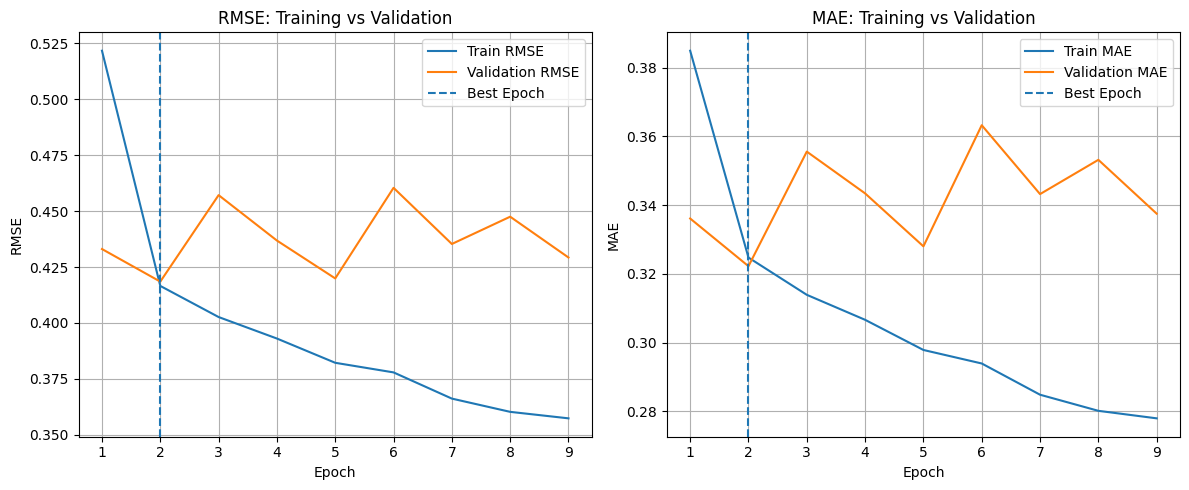

In [57]:
epochs = range(1, len(train_mae_list) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- RMSE plot ---
ax[0].plot(epochs, train_rmse_list, label="Train RMSE")
ax[0].plot(epochs, val_rmse_list, label="Validation RMSE")
ax[0].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[0].set_title("RMSE: Training vs Validation")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("RMSE")
ax[0].legend()
ax[0].grid()

# --- MAE plot ---
ax[1].plot(epochs, train_mae_list, label="Train MAE")
ax[1].plot(epochs, val_mae_list, label="Validation MAE")
ax[1].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[1].set_title("MAE: Training vs Validation")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MAE")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.savefig(model_figs, dpi=300, bbox_inches="tight")
plt.show()

### Evaluation on test set

In [58]:
def collect_predictions(model, df, loader):

    model.eval()

    results = []

    total_time = 0
    total_samples = 0

    running_idx = 0

    with torch.no_grad():

        pbar = tqdm(loader, desc="Evaluating")

        for images, missing_flags, labels in pbar:

            images = images.to(device)
            missing_flags = missing_flags.to(device)
            labels = labels.to(device)

            start = time.time()

            preds = model(images, missing_flags)

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            end = time.time()

            batch_time = end - start

            total_time += batch_time

            batch_size = images.size(0)

            total_samples += batch_size

            preds = preds.cpu().numpy()

            labels_np = labels.cpu().numpy()

            for i in range(batch_size):

                row = df.iloc[running_idx + i]

                results.append({
                    "pred": float(preds[i]),
                    "true": float(labels_np[i]),
                    "gender": row["gender"],
                    "age": row["age"]
                })

            running_idx += batch_size

    results_df = pd.DataFrame(results)

    mae = mean_absolute_error(results_df["true"], results_df["pred"])
    rmse = np.sqrt(mean_squared_error(results_df["true"], results_df["pred"]))
    latency_per_batch = total_time / len(loader)
    latency_per_sample = total_time / total_samples

    return results_df, mae, rmse, latency_per_batch, latency_per_sample

In [59]:
def compute_group_mae(df, group_col):
    group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))
    worst_group = group_mae.max()
    best_group = group_mae.min()
    gap = worst_group - best_group
    return group_mae, worst_group, gap

In [60]:
def compute_fairness_metrics(results_df):
    metrics = {}

    # ---- Gender ----
    gender_mae, gender_worst, gender_gap = compute_group_mae(results_df, "gender")

    metrics["gender"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in gender_mae.items()},
        "worst_group_mae": round(float(gender_worst), 5),
        "gap": round(float(gender_gap), 5)
    }

    # ---- Age ----
    results_df = results_df.copy()
    results_df["age_group"] = pd.cut(results_df["age"], bins=[13, 17, 20, 22, 26, 44])

    age_mae, age_worst, age_gap = compute_group_mae(results_df, "age_group")

    metrics["age"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in age_mae.items()},
        "worst_group_mae": round(float(age_worst), 5),
        "gap": round(float(age_gap), 5)
    }

    return metrics

In [61]:
# replace Nan with None for json export
def replace_nan(d, value=None):
    if isinstance(d, dict):
        return {
            k: replace_nan(v, value)
            for k, v in d.items()
        }
    if isinstance(d, float) and math.isnan(d):
        return value
    return d

In [62]:
# name = 'gru'
# model_path = f"models/CNN Temporal/{name}.pt"
# model_results = f"results/CNN Temporal/{name}_results.json"

model = CNN_GRU().to(device)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

/home/cfragkiadakis/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/cfragkiadakis/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/scratch-local/cfragkiadakis.22775636/ipykernel_128161/2695030227.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/p

CNN_GRU(
  (cnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   

In [63]:
results_df, best_mae, best_rmse, best_latency_batch, best_latency_sample = collect_predictions(model, test_df, test_loader)
fairness_metrics = compute_fairness_metrics(results_df)
results = {
    "mae": round(float(best_mae),4),
    "rmse": round(float(best_rmse),4),
    "latency_per_batch": round(float(best_latency_batch),4),
    "latency_per_sample_ms": round(float(best_latency_sample * 1000),4),
    "fairness": fairness_metrics}

clean_results = replace_nan(results, value=None)
with open(model_results, "w") as f:
    json.dump(clean_results, f, indent=4)

Evaluating: 100%|██████████| 276/276 [04:00<00:00,  1.15it/s]
/scratch-local/cfragkiadakis.22775636/ipykernel_128161/788008378.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))
/scratch-local/cfragkiadakis.22775636/ipykernel_128161/788008378.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))
/scratch-local/cfragkiadakis.22775636

In [64]:
print('MAE:', results['mae'])

MAE: 0.3241


In [65]:
print("MAE per gender:\n", results['fairness']['gender']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['gender']['worst_group_mae']}")
print(f"Gap: {results['fairness']['gender']['gap']}")

MAE per gender:
 {'female': 0.29385, 'male': 0.4039}

Worst-group MAE: 0.4039
Gap: 0.11005


In [66]:
print("MAE per age:\n", results['fairness']['age']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['age']['worst_group_mae']}")
print(f"Gap: {results['fairness']['age']['gap']}")

MAE per age:
 {'(13, 17]': 0.29463, '(17, 20]': 0.22129, '(20, 22]': 0.31533, '(22, 26]': 0.42197, '(26, 44]': 0.29206}

Worst-group MAE: 0.42197
Gap: 0.20068


In [67]:
preds = results_df['pred']
print(preds.min())
print(preds.max())
print(preds.mean())
print(preds.std())

2.363893747329712
3.8991177082061768
2.9625695030885497
0.24440286869085287


In [68]:
mean_pred = train_df["target"].mean()
baseline_mae = (test_df["target"] - mean_pred).abs().mean()

print(mean_pred)
print(baseline_mae)

2.9303739869802046
0.32446265590666756


In [69]:
from sklearn.metrics import r2_score

print(r2_score(test_df['target'], preds))

-0.006954422477057243


In [70]:
results_df["bin"] = pd.cut(
    results_df["true"],
    bins=[1,2,2.5,3,3.5,4,5])

results_df.groupby("bin").apply(
    lambda x: np.mean(
        np.abs(x["true"] - x["pred"])))

/scratch-local/cfragkiadakis.22775636/ipykernel_128161/1453793505.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby("bin").apply(
/scratch-local/cfragkiadakis.22775636/ipykernel_128161/1453793505.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_df.groupby("bin").apply(


bin
(1.0, 2.0]    0.994196
(2.0, 2.5]    0.514446
(2.5, 3.0]    0.171702
(3.0, 3.5]    0.412317
(3.5, 4.0]    0.564125
(4.0, 5.0]    1.106331
dtype: float64